In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-shows/netflix_titles.csv


# Netflix Data Wrangling and Exploratory Data Analysis (EDA)
This notebook performs data wrangling and EDA on the Netflix dataset available from Kaggle.  
I aim to explore, clean, and derive insights from the dataset to prepare it for analysis or visualization.

---
## 🔍 1. Load and Inspect Dataset


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

# Basic info
print("Dataset Shape:", df.shape)
df.info()
df.head()


Dataset Shape: (8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
## 🔎 2. Data Discovery
We check for:
- Data types
- Null values
- Duplicates


In [4]:
# Column names
print(df.columns.tolist())

# Null values
print("Missing values:\n", df.isnull().sum())

# Duplicates
print("Duplicate rows:", df.duplicated().sum())


['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']
Missing values:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Duplicate rows: 0


---
## 🧹 3. Data Cleaning
Includes:
- Converting dates
- Handling nulls
- Splitting duration
- Dropping irrelevant columns


In [10]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop rows with critical nulls
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Fill missing 'cast' and 'country' with 'Not Given'
df['cast'] = df['cast'].fillna('Not Given')
df['country'] = df['country'].fillna('Not Given')

# Drop 'description' for simplicity, ignore error if column doesn't exist
df.drop(columns=['description'], inplace=True, errors='ignore')

# Split duration into value and unit
df[['duration_value', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')
df['duration_value'] = pd.to_numeric(df['duration_value'], errors='coerce')

# Show the first few rows of the cleaned DataFrame
print(df.head())


  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                          Not Given  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...      Not Given   
3                                          Not Given      Not Given   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

---
## 📊 4. Univariate Analysis
Let's look at distribution of content types, ratings, and release years.
* type (e.g., Movie vs TV Show)

* rating (e.g., TV-MA, PG, etc.)

* release_year (to see trends over time)


1. Distribution of Content Types

type
Movie      6126
TV Show    2576
Name: count, dtype: int64


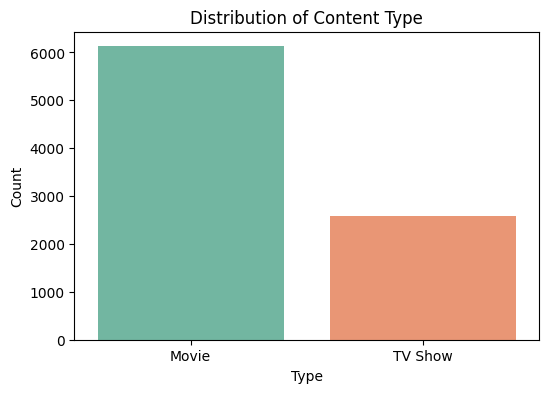

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Check if the column has data
print(df['type'].value_counts())

# Create the plot
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


2. Distribution of Ratings

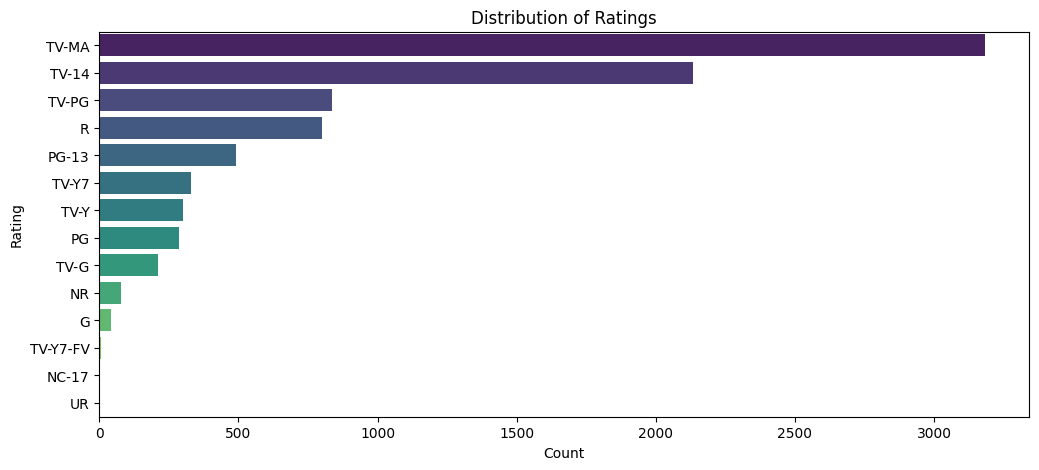

In [18]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


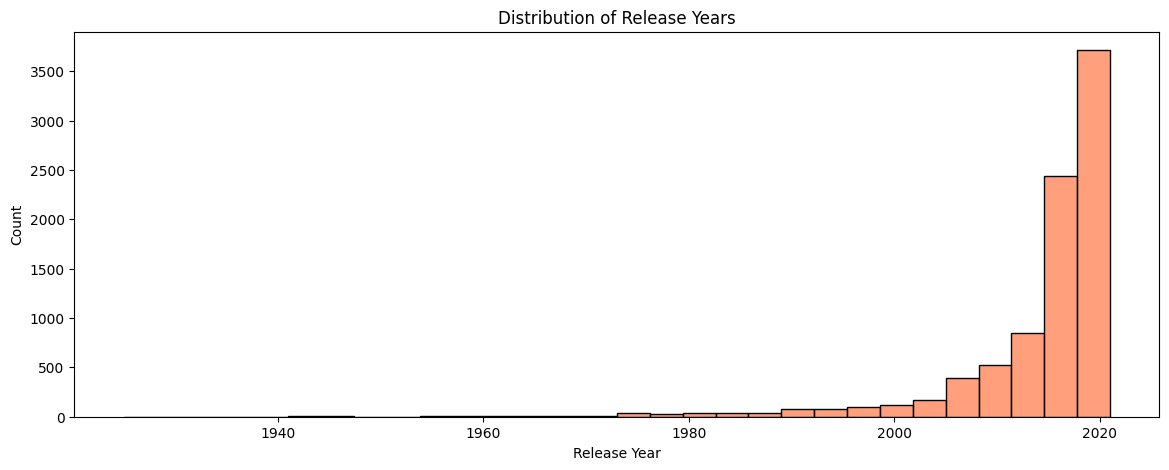

In [19]:
plt.figure(figsize=(14, 5))
sns.histplot(data=df, x='release_year', bins=30, kde=False, color='coral')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()


 3. Distribution of Release Years

 Summary Stats

In [20]:
print(df['type'].value_counts())
print(df['rating'].value_counts())
print(df['release_year'].value_counts().sort_index())


type
Movie      6126
TV Show    2576
Name: count, dtype: int64
rating
TV-MA       3183
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
Name: count, dtype: int64
release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1014
2018    1140
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64


---
## 📉 5. Bivariate & Multivariate Analysis
We analyze:
- Country vs Type
- Year vs Type
- Correlation between numerical features


1. Country vs Type
This shows how content type (Movie/TV Show) is distributed across countries.

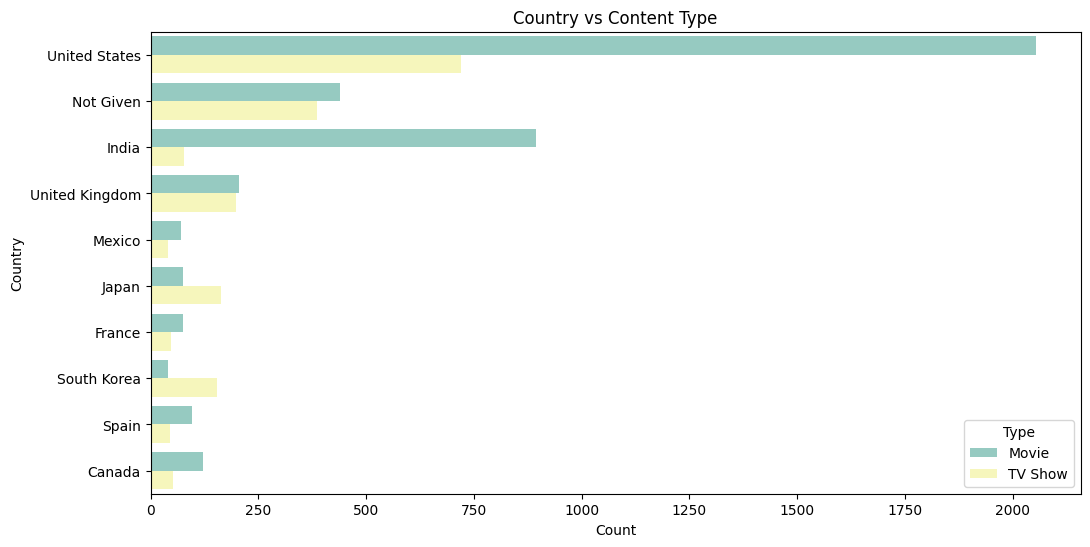

In [21]:
# Top 10 countries by count
top_countries = df['country'].value_counts().nlargest(10).index
filtered_df = df[df['country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.countplot(data=filtered_df, y='country', hue='type', palette='Set3')
plt.title('Country vs Content Type')
plt.xlabel('Count')
plt.ylabel('Country')
plt.legend(title='Type')
plt.show()


2. Release Year vs Type
This explores the number of movies/TV shows added over time.

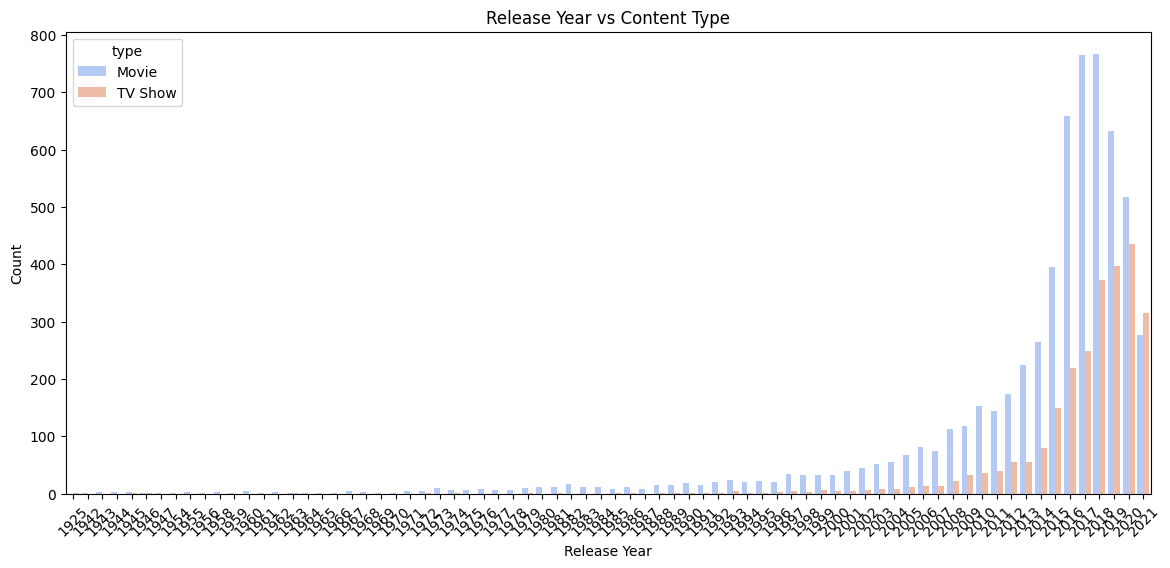

In [22]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='release_year', hue='type', palette='coolwarm', order=sorted(df['release_year'].unique()))
plt.title('Release Year vs Content Type')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


If there are too many years, you can limit to recent years:

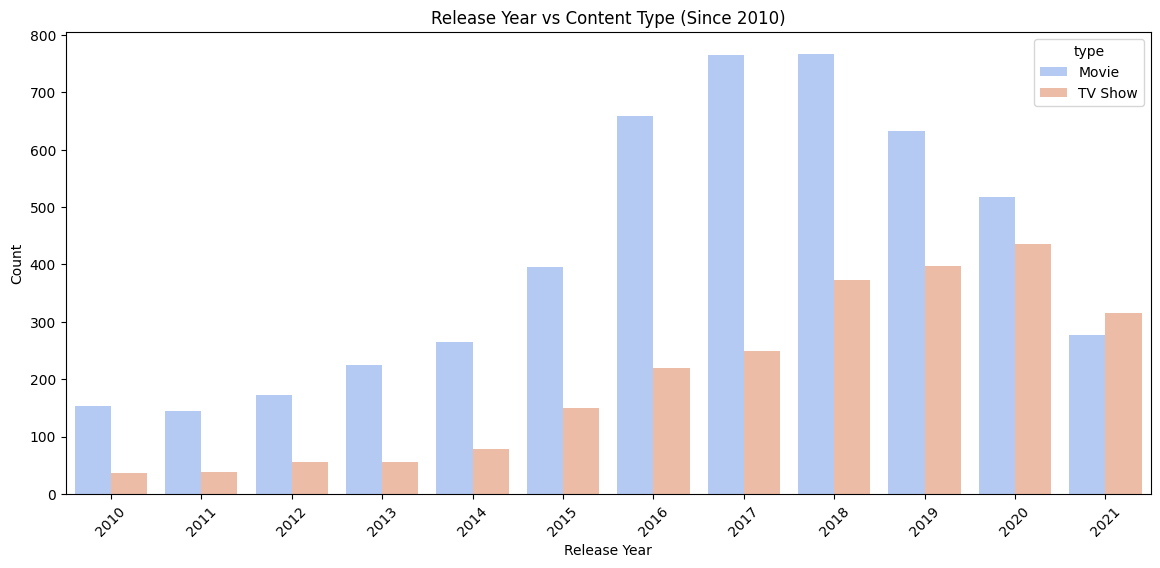

In [23]:
recent_df = df[df['release_year'] >= 2010]
plt.figure(figsize=(14, 6))
sns.countplot(data=recent_df, x='release_year', hue='type', palette='coolwarm')
plt.title('Release Year vs Content Type (Since 2010)')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


3. Correlation Between Numerical Features
We have duration_value, and possibly others (like counts, if you create them). Let's see correlations:

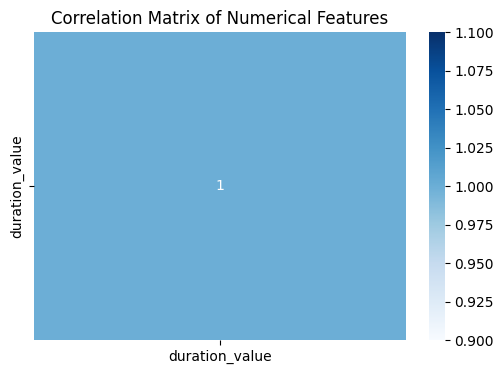

In [24]:
# Select numeric columns
numeric_df = df[['duration_value']].copy()

# Add more numeric features if needed
# Example: content count per country or release_year

# Correlation matrix
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


4. Number of Titles per Year, Country, and Type

In [27]:
# Group by release_year, country, and type
title_counts = df.groupby(['release_year', 'country', 'type']).size().reset_index(name='title_count')

# Display the first few rows
print(title_counts.head())


   release_year                        country     type  title_count
0          1925                      Not Given  TV Show            1
1          1942                  United States    Movie            2
2          1943                  United States    Movie            3
3          1944                  United States    Movie            2
4          1944  United States, United Kingdom    Movie            1


5. Average Duration by Type

In [28]:
# Group by type and calculate average duration
avg_duration = df.groupby('type')['duration_value'].mean().reset_index()

# Display the result
print(avg_duration)


      type  duration_value
0    Movie       99.584884
1  TV Show        1.689053


6. Average Duration by Type and Country

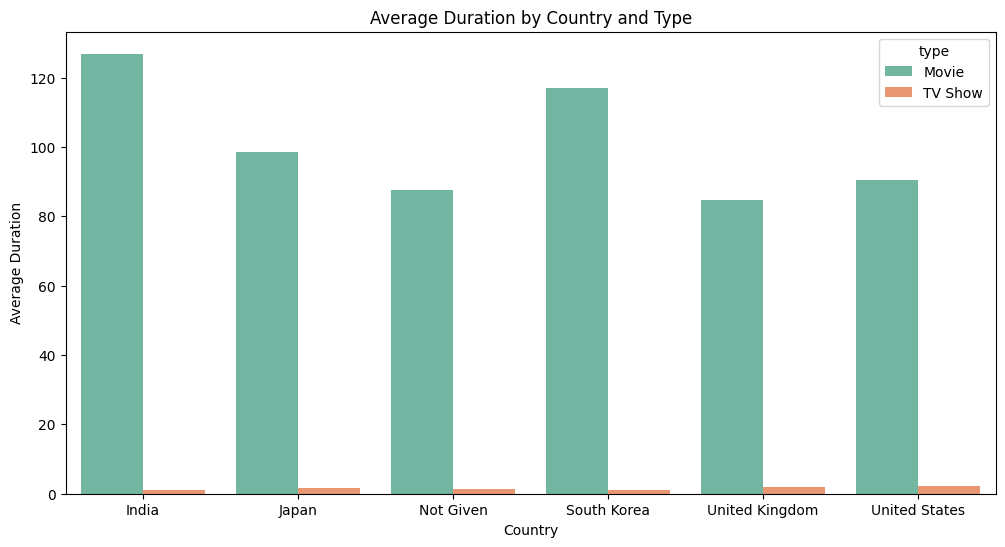

In [29]:
avg_duration_country = df.groupby(['country', 'type'])['duration_value'].mean().reset_index()

# Filter top countries for better readability
top_countries = df['country'].value_counts().nlargest(6).index
filtered_avg_duration = avg_duration_country[avg_duration_country['country'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_avg_duration, x='country', y='duration_value', hue='type', palette='Set2')
plt.title('Average Duration by Country and Type')
plt.xlabel('Country')
plt.ylabel('Average Duration')
plt.show()


---
## ✅ 6. Validation
Final data checks for:
- Types
- Anomalies
- Sample records


A. Data Type Check
You want to ensure each column is of the correct type for future analysis and plotting.

In [30]:
print("✅ Data Types Check:\n")
print(df.dtypes)


✅ Data Types Check:

show_id                   object
type                      object
title                     object
director                  object
cast                      object
country                   object
date_added        datetime64[ns]
release_year               int64
rating                    object
duration                  object
listed_in                 object
duration_value             int64
duration_unit             object
dtype: object


 B. Anomaly Detection
 
 a) Check for Old Content
Identify extremely old or possibly incorrect entries:

In [31]:
old_content = df[df['release_year'] < 1990]
print(f"\n📉 Records released before 1990: {len(old_content)}")



📉 Records released before 1990: 248


In [32]:
old_content[['title', 'release_year', 'type']]


,title,release_year,type
41,Jaws,1975,Movie
42,Jaws 2,1978,Movie
43,Jaws 3,1983,Movie
44,Jaws: The Revenge,1987,Movie
131,Blade Runner: The Final Cut,1982,Movie
...,...,...,...
8739,Why We Fight: The Battle of Russia,1943,Movie
8745,Willy Wonka & the Chocolate Factory,1971,Movie
8748,Winter of Our Dreams,1981,Movie
8763,WWII: Report from the Aleutians,1943,Movie


b) Missing or Zero Durations

In [40]:
print(f"\n🕒 Records with zero duration value: {len(df[df['duration_value'] == 0])}")



🕒 Records with zero duration value: 0


c) Outliers in Duration
Optional: Look at the distribution of durations to catch unusually long or short ones.

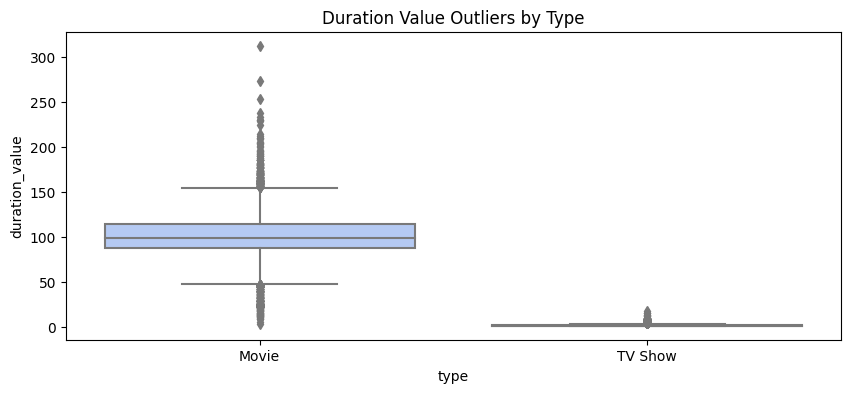

In [42]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='type', y='duration_value', palette='coolwarm')
plt.title('Duration Value Outliers by Type')
plt.show()


C. Sample Records
Just to inspect how the data looks after cleaning:

In [43]:
print("\n🎯 Sample Records:")
df.sample(5)



🎯 Sample Records:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,duration_value,duration_unit
882,s883,Movie,Jungle Beat: The Movie,Brent Dawes,"Ed Kear, David Menkin, Ina Marie Smith, John G...",Mauritius,2021-05-14,2021,TV-Y7,90 min,"Children & Family Movies, Comedies",90,min
3745,s3746,TV Show,Awake: The Million Dollar Game,NaN,James Davis,United States,2019-06-14,2019,TV-PG,1 Season,Reality TV,1,Season
6396,s6397,Movie,Cézanne et moi,Daniele Thompson,"Guillaume Canet, Guillaume Gallienne, Alice Po...","Belgium, France",2017-09-07,2016,R,114 min,"Dramas, Independent Movies, International Movies",114,min
8502,s8503,Movie,The Seven Five,Tiller Russell,Not Given,United States,2017-04-14,2014,R,104 min,Documentaries,104,min
735,s736,Movie,Sarbath,Prabhakaran,"Kathir, Soori, Rahasya Gorak, Ashvatt",India,2021-06-11,2021,TV-PG,113 min,"Comedies, Dramas, International Movies",113,min


---
## 💾 7. Export Cleaned Dataset


In [44]:
df.to_csv('/kaggle/working/cleaned_netflix.csv', index=False)
print("Cleaned dataset exported successfully!")


Cleaned dataset exported successfully!
